In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("25BTIT136.csv")
df

,Unnamed: 0,Make,Model,Year,Mileage,Condition,Price
0,0,Ford,Silverado,2022,18107,Excellent,19094.75
1,1,Toyota,Silverado,2014,13578,Excellent,27321.10
2,2,Chevrolet,Civic,2016,46054,Good,23697.30
3,3,Ford,Civic,2022,34981,Excellent,18251.05
4,4,Chevrolet,Civic,2019,63565,Excellent,19821.85
...,...,...,...,...,...,...,...
996,996,Chevrolet,F-150,2014,20608,Excellent,26969.70
997,997,Ford,Altima,2016,109851,Good,20507.55
998,998,Toyota,Silverado,2010,11704,Good,31414.90
999,999,Nissan,Silverado,2017,128390,Excellent,18580.60


In [5]:
df.head()

,Unnamed: 0,Make,Model,Year,Mileage,Condition,Price
0,0,Ford,Silverado,2022,18107,Excellent,19094.75
1,1,Toyota,Silverado,2014,13578,Excellent,27321.10
2,2,Chevrolet,Civic,2016,46054,Good,23697.30
3,3,Ford,Civic,2022,34981,Excellent,18251.05
4,4,Chevrolet,Civic,2019,63565,Excellent,19821.85


In [6]:
df.shape

(1001, 7)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1001 non-null   int64  
 1   Make        1001 non-null   str    
 2   Model       1001 non-null   str    
 3   Year        1001 non-null   int64  
 4   Mileage     1001 non-null   int64  
 5   Condition   1001 non-null   str    
 6   Price       1001 non-null   float64
dtypes: float64(1), int64(3), str(3)
memory usage: 73.4 KB


In [8]:
df.isnull().sum()

Unnamed: 0    0
Make          0
Model         0
Year          0
Mileage       0
Condition     0
Price         0
dtype: int64

In [9]:
df["Year"] = df["Year"].fillna(df["Year"].mean())
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].mean())
df["Price"] = df["Price"].fillna(df["Price"].mean())

In [10]:
df.isnull().sum()

Unnamed: 0    0
Make          0
Model         0
Year          0
Mileage       0
Condition     0
Price         0
dtype: int64

In [11]:
df["Make"] = df["Make"].fillna(df["Make"].mode()[0])
df["Model"] = df["Model"].fillna(df["Model"].mode()[0])
df["Condition"] = df["Condition"].fillna(df["Condition"].mode()[0])

In [12]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df

,Make,Model,Year,Mileage,Condition,Price
0,Ford,Silverado,2022,18107,Excellent,19094.75
1,Toyota,Silverado,2014,13578,Excellent,27321.10
2,Chevrolet,Civic,2016,46054,Good,23697.30
3,Ford,Civic,2022,34981,Excellent,18251.05
4,Chevrolet,Civic,2019,63565,Excellent,19821.85
...,...,...,...,...,...,...
996,Chevrolet,F-150,2014,20608,Excellent,26969.70
997,Ford,Altima,2016,109851,Good,20507.55
998,Toyota,Silverado,2010,11704,Good,31414.90
999,Nissan,Silverado,2017,128390,Excellent,18580.60


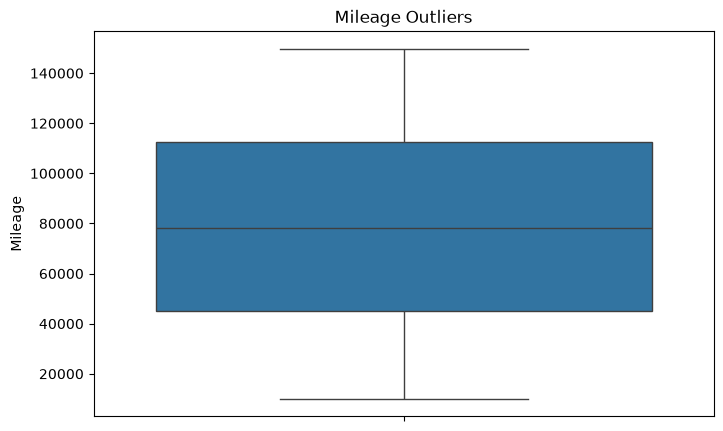

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(df["Mileage"])
plt.title("Mileage Outliers")
plt.show()

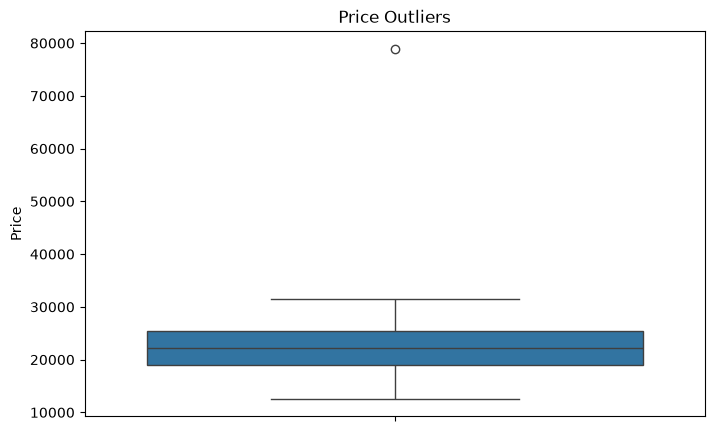

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(df["Price"])
plt.title("Price Outliers")
plt.show()

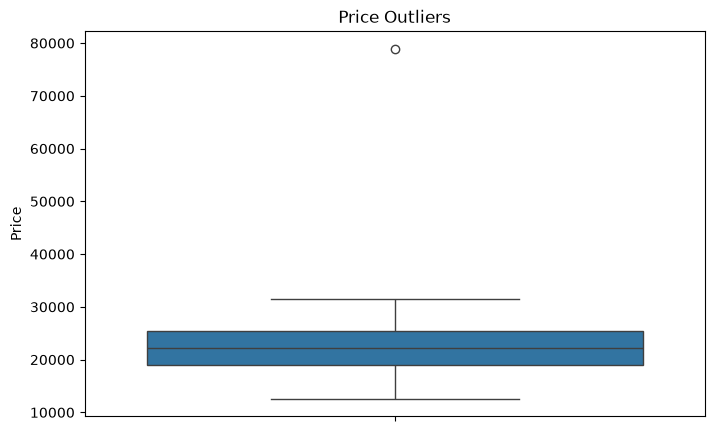

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(df["Price"])
plt.title("Price Outliers")
plt.show()

In [16]:
df[["Year", "Mileage", "Price"]].describe()

,Year,Mileage,Price
count,1001.000000,1001.000000,1001.000000
mean,2015.875125,78853.797203,22251.909640
std,3.794126,39862.961828,4606.754585
min,2010.000000,10079.000000,12613.000000
25%,2013.000000,44962.000000,18965.450000
50%,2016.000000,78256.000000,22261.000000
75%,2019.000000,112469.000000,25520.850000
max,2026.000000,149794.000000,78955.900000


In [18]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Price"] >= lower) & (df["Price"] <= upper)]

In [19]:
df.shape

(1000, 6)

In [20]:
df.describe()

,Year,Mileage,Price
count,1000.00000,1000.000000,1000.000000
mean,2015.86500,78796.927000,22195.205650
std,3.78247,39842.259941,4245.191585
min,2010.00000,10079.000000,12613.000000
25%,2013.00000,44942.750000,18961.862500
50%,2016.00000,78056.500000,22247.875000
75%,2019.00000,112366.250000,25510.275000
max,2022.00000,149794.000000,31414.900000


In [21]:
df.describe()

,Year,Mileage,Price
count,1000.00000,1000.000000,1000.000000
mean,2015.86500,78796.927000,22195.205650
std,3.78247,39842.259941,4245.191585
min,2010.00000,10079.000000,12613.000000
25%,2013.00000,44942.750000,18961.862500
50%,2016.00000,78056.500000,22247.875000
75%,2019.00000,112366.250000,25510.275000
max,2022.00000,149794.000000,31414.900000


In [22]:
le = LabelEncoder()

df["Make"] = le.fit_transform(df["Make"])
df["Model"] = le.fit_transform(df["Model"])
df["Condition"] = le.fit_transform(df["Condition"])

df

,Make,Model,Year,Mileage,Condition,Price
0,1,4,2022,18107,0,19094.75
1,4,4,2014,13578,0,27321.10
2,0,2,2016,46054,2,23697.30
3,1,2,2022,34981,0,18251.05
4,0,2,2019,63565,0,19821.85
...,...,...,...,...,...,...
995,3,1,2010,149032,0,24548.50
996,0,3,2014,20608,0,26969.70
997,1,0,2016,109851,2,20507.55
998,4,4,2010,11704,2,31414.90


In [23]:
le = LabelEncoder()

df["Make"] = le.fit_transform(df["Make"])
df["Model"] = le.fit_transform(df["Model"])
df["Condition"] = le.fit_transform(df["Condition"])

df

,Make,Model,Year,Mileage,Condition,Price
0,1,4,2022,18107,0,19094.75
1,4,4,2014,13578,0,27321.10
2,0,2,2016,46054,2,23697.30
3,1,2,2022,34981,0,18251.05
4,0,2,2019,63565,0,19821.85
...,...,...,...,...,...,...
995,3,1,2010,149032,0,24548.50
996,0,3,2014,20608,0,26969.70
997,1,0,2016,109851,2,20507.55
998,4,4,2010,11704,2,31414.90


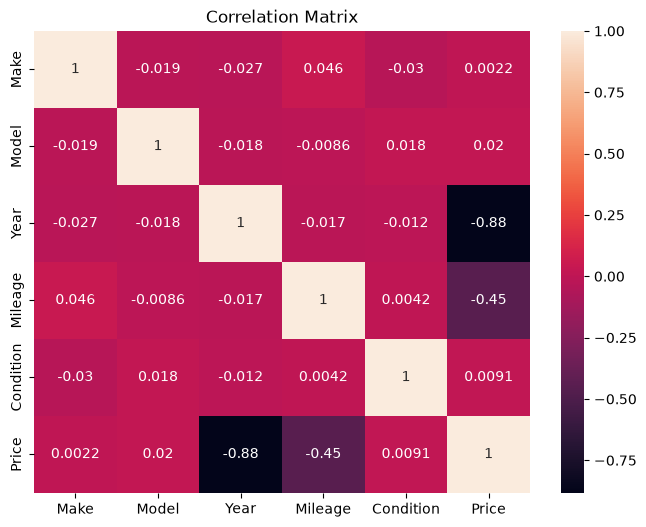

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [25]:
df["Price"].describe()

count     1000.000000
mean     22195.205650
std       4245.191585
min      12613.000000
25%      18961.862500
50%      22247.875000
75%      25510.275000
max      31414.900000
Name: Price, dtype: float64

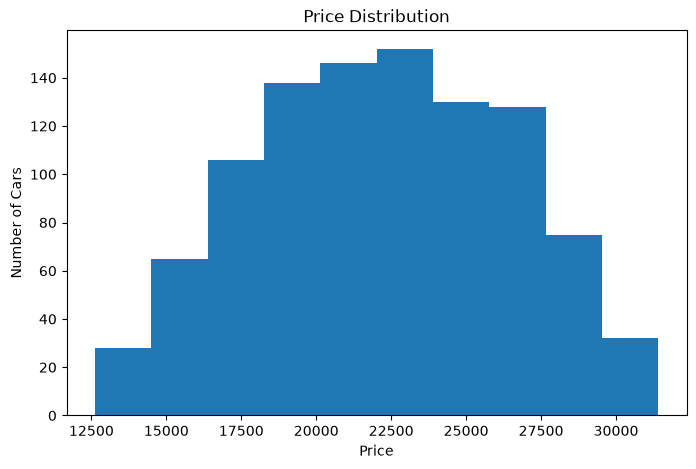

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df["Price"])
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.title("Price Distribution")
plt.show()

In [27]:
X = df[["Make", "Model", "Year", "Mileage", "Condition"]]
Y = df["Price"]

In [28]:
print("X:")
display(X.head())

print("Y:")
display(Y.head())

X:


,Make,Model,Year,Mileage,Condition
0,1,4,2022,18107,0
1,4,4,2014,13578,0
2,0,2,2016,46054,2
3,1,2,2022,34981,0
4,0,2,2019,63565,0


Y:


0    19094.75
1    27321.10
2    23697.30
3    18251.05
4    19821.85
Name: Price, dtype: float64

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

In [31]:
X_normalized = (X - X.min()) / (X.max() - X.min())

In [32]:
X_normalized = (X - X.min()) / (X.max() - X.min())

In [33]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. , -0. ,-3759.41,-1972.13, -0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.216e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[29.87,28.5 ,28.06,27.76,27.16]"


In [35]:
Y_pred = model.predict(X_test)
Y_pred

array([30510.51093755, 24488.70383783, 30455.41011337, 24797.45057461,
       21920.60235263, 27172.85856772, 29334.74840802, 29353.00397967,
       24816.64015278, 22315.34493854, 15522.50685328, 22844.26585679,
       23952.65919443, 19333.34002708, 24140.9951052 , 29955.59540378,
       19806.95167731, 18164.30878625, 27749.84937008, 30366.56153767,
       22045.85395098, 22267.29273629, 22666.1950264 , 26189.54775912,
       24595.04835149, 13017.50776665, 17755.81365192, 22632.66617253,
       20164.34893162, 19363.20474489, 21446.14592789, 19536.49954128,
       16647.1600083 , 20621.60974395, 20665.26016012, 21025.50588217,
       24163.1621824 , 22422.54433091, 28286.75363395, 26409.60660426,
       25016.6548595 , 24139.70743732, 18930.40846504, 26397.39418528,
       23631.1903012 , 24577.99567951, 21473.15216219, 19519.4970718 ,
       18313.29823704, 20009.65106153, 14662.70699393, 14664.1091185 ,
       19163.30725145, 23201.01136651, 16966.79828906, 28285.30583201,
      

In [36]:
print("Actual Price:")
print(Y_test.values)

print("\nPredicted Price:")
print(Y_pred)

Actual Price:
[30510.55 24488.75 30455.25 24797.4  21920.65 27172.9  29334.8  29353.05
 24816.7  22315.4  15522.55 22844.3  23952.7  19333.3  24141.05 29955.55
 19806.9  18164.35 27749.9  30366.5  22045.9  22267.25 22666.25 26189.5
 24595.1  13017.55 17755.85 22632.7  20164.4  19363.25 21446.2  19536.45
 16647.   20621.65 20665.1  21025.55 24163.1  22422.6  28286.7  26409.65
 25016.7  24139.65 18930.45 26397.35 23631.15 24577.95 21473.2  19519.45
 18313.35 20009.7  14662.75 14664.05 19163.35 23201.05 16966.65 28285.25
 25687.75 17365.45 13049.8  14615.45 20625.95 22145.85 20557.8  19830.15
 23291.05 15447.5  17784.25 28911.4  25203.5  25842.9  27182.05 19433.2
 23313.85 22532.15 19518.9  29561.9  19579.7  16318.75 22607.6  16114.85
 22515.7  18383.1  25434.75 24568.15 21780.3  20087.3  31414.9  25008.8
 26310.85 30366.8  21099.3  22406.65 22881.8  16865.75 26263.3  24260.95
 12706.9  20031.9  25024.7  25853.8  23854.85 28411.35 21948.5  14822.65
 25159.05 20323.   21322.5  26046.6  150

In [37]:
mse = mean_squared_error(Y_test, Y_pred)
mse

0.004725039353084063

In [38]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 0.06873892167530753


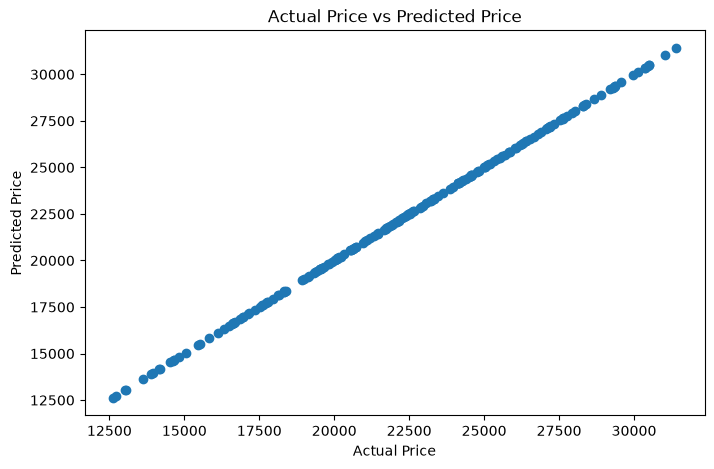

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(Y_test, Y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()

In [40]:
new_data = np.array([[2, 1, 2022, 30000, 2]])

new_data_df = pd.DataFrame(
    new_data,
    columns=X.columns
)

new_data_scaled = scaler.transform(new_data_df)

prediction = model.predict(new_data_scaled)

print("Predicted Car Price:", prediction[0])

Predicted Car Price: 18500.05397576843
